# Federal disaster declarations by county

FEMA's Disaster Declarations Summaries list every federally declared
disaster since 1953: major disasters (`DR`), emergencies (`EM`), and fire
management declarations (`FM`). OpenFEMA serves them through its v2 API,
and a request returns CSV with one row per declaration and designated area,
a county, a tribal area, or a whole state, carrying the incident type and
period, the assistance programs declared, and state and county FIPS codes.

This walkthrough pulls every declaration in Oklahoma whose incident fell
between 2000 and 2024 and counts them by year and type. It needs
`usdata[pandas]` and matplotlib; the CSV is under 1 MB and the run takes a
few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:09:18+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names a state and a window. `location: Oklahoma` becomes the
state FIPS code `40`; a county such as `Osage County, OK` would narrow it
further, and a bounding box is refused because the rows carry no
coordinates. The window selects declarations whose **incident period**
overlaps it, not those declared inside it. Incidents with no end date are
left out unless `include_open: true` asks for them, because many old fire
declarations were never closed and would otherwise match every later window.
`declaration_type` and `incident_type` parameters would narrow the rows.

In [2]:
print(manifest.read_text())

name: oklahoma-declarations
sources:
  - name: declarations
    dataset: fema:disaster-declarations
    # Declarations whose incident period overlaps the window, in any Oklahoma area.
    location: Oklahoma
    start: 2000-01-01
    end: 2024-12-31



## What arrives

Listing asks OpenFEMA for the count first, then makes one asset per page of
10,000 rows ordered by declaration date. Oklahoma's quarter century fits on
one page. The source URL shows the filter the window and place became. The
first pull writes `dataset.lock.json` beside the manifest with the page's
checksum.

In [3]:
result = pull(manifest)
pages = result.by_source["declarations"]
print("Pages:", len(pages))
item = pages[0]
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

Pages: 1
File: declarations_20000101_20241231_8f690fb627e069c63783.csv
Bytes: 746502
Source: https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?%24filter=incidentBeginDate+le+%272024-12-31%27+and+incidentEndDate+ge+%272000-01-01%27+and+fipsStateCode+eq+%2740%27&%24orderby=declarationDate%2Cid&%24top=10000&%24skip=0&%24format=csv
Retrieved (UTC): 2026-09-24T06:09:18+00:00
Checksum: sha256:dd799269f0da25055837ac6a432cce80e4be1a79552add132cd1991e5e1c8ff0


## Open

The generic CSV reader returns a DataFrame and keeps `fipsStateCode`,
`fipsCountyCode`, and `placeCode` as text, so `019` stays `019`. Dates are
calendar dates at midnight UTC; `parse_dates` makes them timestamps. The
program columns (`ihProgramDeclared` and the rest) are `0` or `1`.

One declaration is many rows, one per designated area, so count
declarations with `disasterNumber`, not rows. County code `000` is not a
county: it marks a statewide designation or a tribal area, which
`designatedArea` names.

In [4]:
declarations = item.open_csv(
    parse_dates=["declarationDate", "incidentBeginDate", "incidentEndDate"]
)
distinct = declarations.drop_duplicates("disasterNumber")
print(f"{len(declarations)} rows for {len(distinct)} declarations")
print("By type:", distinct["declarationType"].value_counts().to_dict())
areas = declarations.groupby("disasterNumber").size()
print(f"Areas per declaration: median {areas.median():.0f}, maximum {areas.max()}")
statewide = declarations["fipsCountyCode"].eq("000")
print(f"Rows with county code 000: {statewide.sum()}, such as", end=" ")
print(", ".join(declarations.loc[statewide, "designatedArea"].unique()[:3]))
shown = ["femaDeclarationString", "incidentType", "incidentBeginDate", "designatedArea"]
declarations[shown].tail()

2062 rows for 137 declarations
By type: {'DR': 60, 'FM': 52, 'EM': 25}
Areas per declaration: median 1, maximum 112
Rows with county code 000: 92, such as Statewide, Pawnee (OTSA), Creek (OTSA)


,femaDeclarationString,incidentType,incidentBeginDate,designatedArea
2057,DR-4862-OK,Severe Storm,2024-11-02 00:00:00+00:00,Jefferson (County)
2058,DR-4862-OK,Severe Storm,2024-11-02 00:00:00+00:00,Lincoln (County)
2059,DR-4862-OK,Severe Storm,2024-11-02 00:00:00+00:00,Garvin (County)
2060,DR-4862-OK,Severe Storm,2024-11-02 00:00:00+00:00,Washita (County)
2061,DR-4862-OK,Severe Storm,2024-11-02 00:00:00+00:00,Oklahoma (County)


## A first look

Declarations per year, by the year the incident began, stacked by type.

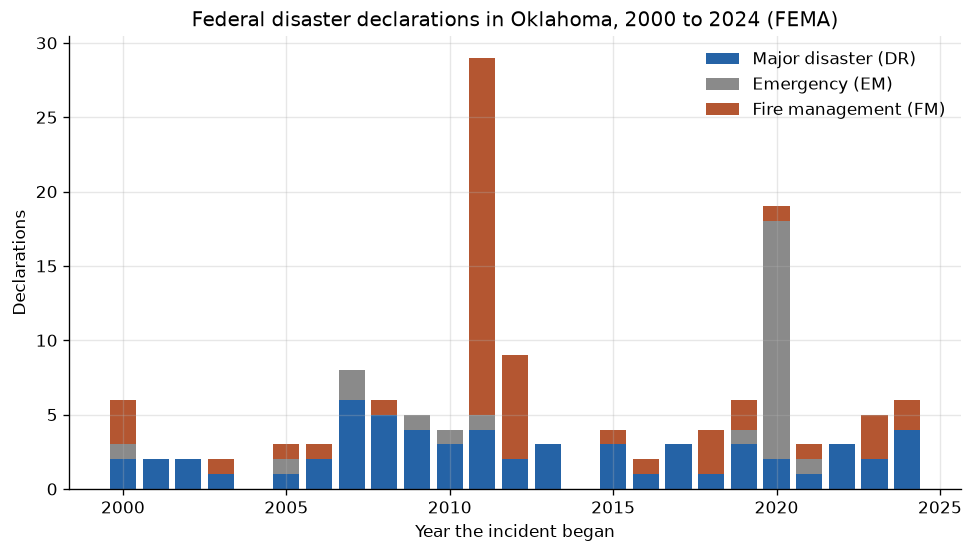

In [5]:
kinds = {"DR": "Major disaster (DR)", "EM": "Emergency (EM)", "FM": "Fire management (FM)"}
colors = {"DR": "#2563a6", "EM": "#8a8a8a", "FM": "#b45631"}
per_year = (
    distinct.groupby([distinct["incidentBeginDate"].dt.year, "declarationType"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(2000, 2025), columns=list(kinds), fill_value=0)
)
fig, ax = plt.subplots(layout="constrained")
bottom = pd.Series(0, index=per_year.index)
for code, label in kinds.items():
    ax.bar(per_year.index, per_year[code], bottom=bottom, color=colors[code], label=label)
    bottom += per_year[code]
ax.set_xlabel("Year the incident began")
ax.set_ylabel("Declarations")
ax.set_title("Federal disaster declarations in Oklahoma, 2000 to 2024 (FEMA)")
ax.legend(frameon=False)
plt.show()

In [6]:
print("Totals:", per_year.sum().to_dict())
print(f"Fire management in 2011: {per_year.loc[2011, 'FM']}")
covid = distinct[distinct["declarationTitle"].eq("COVID-19")]
tribal = covid["tribalRequest"].sum()
print(f"COVID-19 declarations: {len(covid)}, {tribal} requested by tribal nations")
major = declarations[declarations["declarationType"].eq("DR") & ~statewide]
top = major.groupby("designatedArea")["disasterNumber"].nunique().nlargest(3)
print("Counties named in the most major disasters:", top.to_dict())
dr_types = distinct.loc[distinct["declarationType"].eq("DR"), "incidentType"]
print("Major disasters by incident type:", dr_types.value_counts().to_dict())

Totals: {'DR': 60, 'EM': 25, 'FM': 52}
Fire management in 2011: 24
COVID-19 declarations: 16, 15 requested by tribal nations
Counties named in the most major disasters: {'Caddo (County)': 26, 'Okfuskee (County)': 26, 'Okmulgee (County)': 24}
Major disasters by incident type: {'Severe Storm': 41, 'Severe Ice Storm': 8, 'Fire': 4, 'Tornado': 4, 'Flood': 2, 'Biological': 1}


Oklahoma had 60 major disasters in 25 years, more than two a year, and 41 of
them were filed as severe storms. The two spikes are of other kinds: 2011's drought-year wildfires brought two dozen
fire management declarations, and 2020's COVID-19 emergencies were mostly
requested directly by tribal nations, each for its own area. A county named
in 26 major disasters in 25 years says as much about how declarations are
drawn, many counties at once, as about how often that county is struck.

## Pin and cite

`verify` checks the cached page against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same. FEMA
asks that the citation carry the date and time of retrieval.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

fema:disaster-declarations
  Federal Emergency Management Agency (FEMA), OpenFEMA Dataset: Disaster Declarations Summaries - v2. Retrieved from https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries on [date, time]. This product uses the Federal Emergency Management Agency's OpenFEMA API, but is not endorsed by FEMA. The Federal Government or FEMA cannot vouch for the data or analyses derived from these data after the data have been retrieved from the Agency's website(s).
  homepage: https://www.fema.gov/openfema-data-page/disaster-declarations-summaries-v2
  license: US Government Work (public domain)
  terms: https://www.fema.gov/about/openfema/terms-conditions
  retrieved: 2026-09-24; 1 checksummed asset (746,502 bytes) pinned by usdata 0.26.0
  sources: declarations


## What was awkward

- Rows are declaration-areas, so every count has to pick its unit first:
  137 declarations here are over two thousand rows, and one declaration
  names more than a hundred areas.
- `incidentType` is coarse. Severe winter storms are filed as
  `Severe Storm` or `Severe Ice Storm`, and a declaration titled "severe
  storms, straight-line winds, and tornadoes" can be either `Tornado` or
  `Severe Storm`; `declarationTitle` and `designatedIncidentTypes` say more.
- The window selects by incident period, which is the right question for
  "was this place declared for this event", and surprising for "what did FEMA
  declare this year": a declaration made in January for a December storm
  belongs to the storm's year.
- Incidents with no end date are left out by default, which silently drops a
  disaster still under way. `include_open: true` brings it back along with
  decades-old fire declarations that were never closed.
- FEMA's required citation text ends "Retrieved from ... on [date, time]",
  and the placeholder prints as written; the retrieval date is on the next
  line, and the time is in the lockfile, so filling it in is left to you.
- Joining to Storm Events needs the county code padded:
  `CZ_FIPS.str.zfill(3)`. Both keep it as text, but Storm Events writes `1`
  where FEMA writes `001`. The
  [disaster declarations study](https://usdata.dev/studies/disaster-declarations/)
  does that join, and the
  [declarations guide](https://docs.usdata.dev/providers/fema-disaster-declarations/)
  covers the service's other surprises.